## The k-NN classifier

### 1. k-NN classifier using a toy dataset

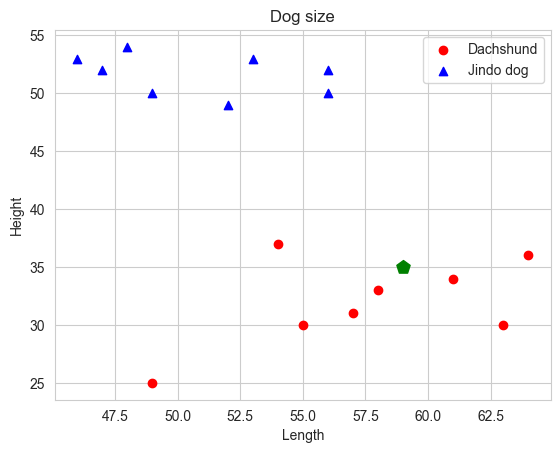

In [1]:
import matplotlib.pyplot as plt  # 그래프를 그리기 위해 matplotlib의 pyplot 모듈을 불러온다.

# 닥스훈트의 몸길이와 키 데이터를 리스트로 저장한다.
dach_length = [55, 57, 64, 63, 58, 49, 54, 61]
dach_height = [30, 31, 36, 30, 33, 25, 37, 34]

# 진돗개의 몸길이와 키 데이터를 리스트로 저장한다.
jin_length = [56, 47, 56, 46, 49, 53, 52, 48]
jin_height = [52, 52, 50, 53, 50, 53, 49, 54]

# 분류할 새 데이터의 몸길이와 키를 리스트로 저장한다.
newdata_length = [59]
newdata_height = [35]

# 닥스훈트 데이터를 빨간색 원형 점으로 그린다.
plt.scatter(dach_length, dach_height, c='r', label='Dachshund')
# 진돗개 데이터를 파란색 삼각형 점으로 그린다.
plt.scatter(jin_length, jin_height, c='b', marker='^', label='Jindo dog')

# x축 이름을 몸길이로 지정한다.
plt.xlabel('Length')
# y축 이름을 키로 지정한다.
plt.ylabel('Height')
# 그래프 제목을 지정한다.
plt.title("Dog size")
# 범례를 오른쪽 위에 표시한다.
plt.legend(loc='upper right')

# 새 데이터는 초록색 오각형 점으로 표시하고 범례 이름을 지정한다.
plt.scatter(newdata_length, newdata_height, s=100, marker='p',
            c='g', label='new Data')


### Stack the data together

In [2]:
import numpy as np  # 배열 계산을 위해 NumPy를 불러온다.

# 닥스훈트의 몸길이와 키를 열 방향으로 합쳐 2차원 데이터로 만든다.
d_data = np.column_stack((dach_length, dach_height))
# 닥스훈트 라벨은 0으로 지정한다.
d_label = np.zeros(len(d_data))

# 진돗개의 몸길이와 키를 열 방향으로 합쳐 2차원 데이터로 만든다.
j_data = np.column_stack((jin_length, jin_height))
# 진돗개 라벨은 1로 지정한다.
j_label = np.ones(len(j_data))

# 닥스훈트와 진돗개 데이터를 하나의 학습 데이터로 합친다.
dogs = np.concatenate((d_data, j_data))
# 두 품종의 라벨도 하나의 라벨 배열로 합친다.
labels = np.concatenate((d_label, j_label))

# 숫자 라벨을 실제 품종 이름으로 바꾸기 위한 딕셔너리를 만든다.
dog_classes = {0: '닥스훈트', 1: '진돗개'}

# 합쳐진 강아지 데이터와 라벨을 출력한다.
print('dogs:', dogs)
print('labels:', labels)


dogs: [[55 30]
 [57 31]
 [64 36]
 [63 30]
 [58 33]
 [49 25]
 [54 37]
 [61 34]
 [56 52]
 [47 52]
 [56 50]
 [46 53]
 [49 50]
 [53 53]
 [52 49]
 [48 54]]
labels: [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.]


### Classify using the k-NN classifier

In [3]:
from sklearn.neighbors import KNeighborsClassifier  # k-NN 분류기를 불러온다.

# 분류할 새 데이터의 몸길이와 키를 2차원 리스트로 저장한다.
newdata = [[59, 35]]

# 가까운 이웃의 개수를 3으로 지정한다.
k = 3
# k가 3인 k-NN 분류기 객체를 만든다.
knn = KNeighborsClassifier(n_neighbors=k)
# 강아지 데이터와 라벨로 k-NN 분류기를 학습시킨다.
knn.fit(dogs, labels)
# 새 데이터의 품종 라벨을 예측한다.
y_pred = knn.predict(newdata)
# 예측된 숫자 라벨을 품종 이름으로 바꾸어 출력한다.
print('data', newdata, ', classified as:', dog_classes[y_pred[0]])


data [[59, 35]] , classified as: 닥스훈트


### Visualize the nearest neighbors

dist = [[2.23606798 2.23606798 4.47213595]] indexes = [[4 7 1]] dogs[indexes]= [[[58 33]
  [61 34]
  [57 31]]]
data [[59, 35]] , classified as: 닥스훈트


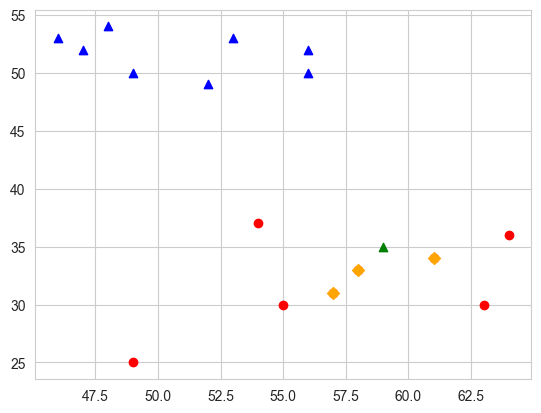

In [4]:
# 새 데이터와 가장 가까운 k개의 이웃 거리와 인덱스를 구한다.
distances, indexes = knn.kneighbors(newdata)
# 거리, 인덱스, 실제 이웃 데이터를 출력해서 확인한다.
print('dist =', distances, 'indexes =', indexes, 'dogs[indexes]=', dogs[indexes])

# 가장 가까운 이웃들을 그래프에 주황색 마름모로 표시하는 함수를 정의한다.
def draw_neighbor(data, index, k):
    # k개의 가까운 이웃을 하나씩 그래프에 표시한다.
    for i in range(k):
        plt.scatter(data[index][0][i][0], dogs[index][0][i][1], marker='D', color='orange')

# 새 데이터를 초록색 삼각형으로 표시한다.
plt.scatter(59, 35, color='green', marker='^')
# 닥스훈트 데이터를 빨간색 점으로 표시한다.
plt.scatter(dach_length, dach_height, c='red', label='Dachshund')
# 진돗개 데이터를 파란색 삼각형으로 표시한다.
plt.scatter(jin_length, jin_height, c='blue', marker='^', label='Jindo dog')

# 새 데이터와 가까운 이웃들을 그래프에 추가한다.
draw_neighbor(dogs, indexes, k)
# 새 데이터의 최종 분류 결과를 출력한다.
print('data', newdata, ', classified as:', dog_classes[y_pred[0]])


### Classifying iris using k-NN Classifier

In [5]:
from sklearn.datasets import load_iris  # 사이킷런에서 붓꽃 데이터를 불러오는 함수를 가져온다.

# 붓꽃 데이터셋을 로드한다.
iris = load_iris()
# 전체 데이터 중 처음 3개 행을 확인한다.
iris.data[:3]


array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2]])

In [6]:
# 붓꽃 데이터의 행과 열 개수를 출력한다.
print('iris data shape:', iris.data.shape)


iris data shape: (150, 4)


In [7]:
# 붓꽃 데이터의 특성 이름을 출력한다.
print('iris data features:', iris.feature_names)


iris data features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [8]:
# 붓꽃 데이터의 정답 라벨 배열을 출력한다.
print('iris data labels:', iris.target)


iris data labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


### Not necessary, but let's transform the data in to a Pandas DataFrame

In [9]:
import pandas as pd  # 표 형태 데이터 처리를 위해 pandas를 불러온다.

# 붓꽃 특성 데이터를 데이터프레임으로 변환하고 열 이름을 지정한다.
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
# 정답 라벨을 target 열로 추가한다.
iris_df['target'] = pd.Series(iris.target)
# 데이터프레임의 앞부분을 확인한다.
iris_df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
# 각 특성의 기초 통계량을 확인한다.
iris_df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [11]:
# 데이터프레임의 앞 5개 행을 확인한다.
iris_df.head(5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
# 앞의 4개 열을 입력 특성 X로 분리한다.
X = iris_df.iloc[:, :4]
# 마지막 열인 target을 정답 라벨 y로 분리한다.
y = iris_df.iloc[:, -1]


In [13]:
from sklearn.model_selection import train_test_split  # 학습 데이터와 테스트 데이터를 나누는 함수를 불러온다.
from sklearn.neighbors import KNeighborsClassifier  # k-NN 분류기를 불러온다.
from sklearn import metrics  # 정확도 계산을 위한 평가 지표 모듈을 불러온다.

# 입력 데이터 X와 정답 y를 받아 k-NN 정확도를 계산하는 함수를 정의한다.
def iris_knn(X, y, k):
    # 데이터를 학습용 70%, 테스트용 30%로 나눈다.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=11)
    # 지정한 k값으로 k-NN 분류기를 만든다.
    knn = KNeighborsClassifier(n_neighbors=k)
    # 학습 데이터로 분류기를 학습시킨다.
    knn.fit(X_train, y_train)
    # 테스트 데이터의 라벨을 예측한다.
    y_pred = knn.predict(X_test)
    # 실제 라벨과 예측 라벨을 비교해 정확도를 반환한다.
    return metrics.accuracy_score(y_test, y_pred)

# 가까운 이웃의 개수를 3으로 설정한다.
k = 3
# k가 3일 때의 정확도를 계산한다.
scores = iris_knn(X, y, k)
# 계산된 정확도를 출력한다.
print('n_neighbors가 {0:d}일때 정확도: {1:.3f}'.format(k, scores))


n_neighbors가 3일때 정확도: 0.956


### Observe the accuracy for different k-values

In [14]:
# 여러 k값에 대해 정확도가 어떻게 달라지는지 반복해서 확인한다.
for i in [1, 5, 10, 20, 30]:
    # 현재 k값으로 k-NN 정확도를 계산한다.
    scores = iris_knn(X, y, i)
    # 현재 k값과 정확도를 출력한다.
    print('n_neighbors가 {0:d}일때 정확도: {1:.3f}'.format(i, scores))


n_neighbors가 1일때 정확도: 0.933
n_neighbors가 5일때 정확도: 0.978
n_neighbors가 10일때 정확도: 0.956
n_neighbors가 20일때 정확도: 0.933
n_neighbors가 30일때 정확도: 0.911


### Apply the model to a new data for classification



In [15]:
from sklearn.datasets import load_iris  # 붓꽃 데이터셋을 불러오는 함수를 가져온다.
from sklearn.neighbors import KNeighborsClassifier  # k-NN 분류기를 불러온다.

# 가까운 이웃의 개수를 3으로 설정한다.
k = 3
# 붓꽃 데이터셋을 다시 로드한다.
iris = load_iris()
# k가 3인 k-NN 분류기 객체를 만든다.
knn = KNeighborsClassifier(n_neighbors=k)
# 전체 붓꽃 데이터로 분류기를 학습시킨다.
knn.fit(iris.data, iris.target)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [16]:
# 숫자 라벨을 붓꽃 품종 이름으로 바꾸기 위한 딕셔너리를 만든다.
classes = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

# 예측할 새로운 붓꽃 데이터를 제시한다.
X = [[4, 2, 1.3, 0.4],
     [4, 3, 3.2, 2.2]]
# 학습된 모델로 새 데이터의 품종을 예측한다.
y = knn.predict(X)

# 첫 번째 새 데이터의 예측 품종을 출력한다.
print('iris with the features {}: {}'.format(X[0], classes[y[0]]))
# 두 번째 새 데이터의 예측 품종을 출력한다.
print('iris with the features {}: {}'.format(X[1], classes[y[1]]))


iris with the features [4, 2, 1.3, 0.4]: setosa
iris with the features [4, 3, 3.2, 2.2]: versicolor


In [17]:
# 전체 붓꽃 데이터에 대해 예측 라벨을 만든다.
y_pred_all = knn.predict(iris.data)
# 전체 데이터의 실제 라벨과 예측 라벨을 비교해 정확도를 계산한다.
scores = metrics.accuracy_score(iris.target, y_pred_all)
# k값과 정확도를 출력한다.
print('accuracy with k = {0:d}: {1:.3f}'.format(k, scores))


accuracy with k = 3: 0.960


In [18]:
from sklearn.metrics import confusion_matrix  # 혼동 행렬을 만드는 함수를 불러온다.

# 실제 라벨과 예측 라벨을 비교해 혼동 행렬을 만든다.
conf_result = confusion_matrix(iris.target, y_pred_all)
# 혼동 행렬을 출력한다.
print(conf_result)


[[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]


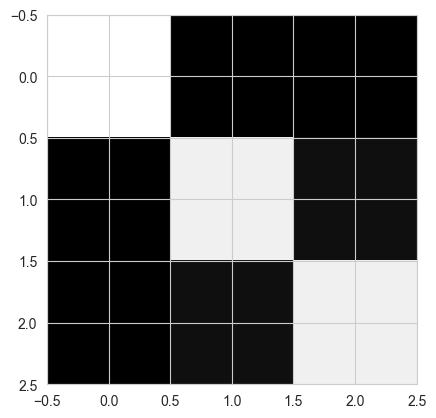

In [19]:
import matplotlib.pyplot as plt  # 혼동 행렬을 이미지로 표시하기 위해 pyplot을 불러온다.

# 혼동 행렬을 회색 계열 이미지로 시각화한다.
plt.imshow(conf_result, cmap='grey')


---

## Assignment: Implement k-NN from Scratch for Iris Classification

In the previous cells, we used `KNeighborsClassifier` from scikit-learn.  
In this assignment, you will solve the **same iris classification problem**, but you must implement the k-NN algorithm yourself using NumPy.

### Rules

- Do **not** use `sklearn.neighbors.KNeighborsClassifier` in this assignment section.
- You may use `sklearn.datasets.load_iris()` only to load the dataset.
- You may use NumPy, pandas, and matplotlib.
- Fill in every `TODO` block.

### What you will implement

1. Feature standardization
2. Euclidean distance
3. Distance matrix computation
4. k nearest neighbor search and majority voting
5. Prediction for all test samples
6. Accuracy and confusion matrix
7. Experiments with different values of `k`

In [20]:
# 과제에서 사용할 기본 모듈과 데이터를 준비한다.
import numpy as np  # 배열 계산을 위해 NumPy를 불러온다.
import matplotlib.pyplot as plt  # 그래프를 그리기 위해 pyplot을 불러온다.
from sklearn.datasets import load_iris  # 붓꽃 데이터셋을 불러오는 함수를 가져온다.

# 붓꽃 데이터셋을 로드한다.
iris = load_iris()
# 입력 특성을 float64 자료형 배열로 저장한다.
X_all = iris.data.astype(np.float64)
# 정답 라벨을 정수형 배열로 저장한다.
y_all = iris.target.astype(int)
# 품종 이름과 특성 이름을 따로 저장한다.
class_names = iris.target_names
feature_names = iris.feature_names

# 데이터의 크기, 라벨 크기, 품종 이름, 특성 이름을 출력한다.
print('X shape:', X_all.shape)
print('y shape:', y_all.shape)
print('classes:', class_names)
print('features:', feature_names)


X shape: (150, 4)
y shape: (150,)
classes: ['setosa' 'versicolor' 'virginica']
features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


### Data preparation: train/test split

The train/test split is provided here so that the assignment can focus on implementing the k-NN algorithm itself.

We will randomly shuffle the dataset and use 70% for training and 30% for testing.

In [21]:
# 학습 데이터와 테스트 데이터를 직접 나누기 위한 준비를 한다.

# 난수 결과가 매번 같도록 시드를 고정한다.
np.random.seed(42)

# 전체 샘플 개수를 구한다.
n_samples = len(X_all)
# 전체 인덱스를 무작위 순서로 섞는다.
indices = np.random.permutation(n_samples)

# 학습 데이터 비율을 70%로 설정한다.
train_ratio = 0.7
# 학습 데이터 개수를 계산한다.
n_train = int(n_samples * train_ratio)

# 섞인 인덱스 중 앞부분은 학습용으로 사용한다.
train_idx = indices[:n_train]
# 나머지 인덱스는 테스트용으로 사용한다.
test_idx = indices[n_train:]

# 학습용 입력 데이터와 정답 라벨을 만든다.
X_train = X_all[train_idx]
y_train = y_all[train_idx]
# 테스트용 입력 데이터와 정답 라벨을 만든다.
X_test = X_all[test_idx]
y_test = y_all[test_idx]

# 학습 데이터와 테스트 데이터의 크기를 출력한다.
print('Train:', X_train.shape, y_train.shape)
print('Test :', X_test.shape, y_test.shape)


Train: (105, 4) (105,)
Test : (45, 4) (45,)


### Step 1. Standardize the features (scaling 하는 과정)

k-NN is based on distance. If one feature has a much larger scale than another feature, it can dominate the distance calculation.

Use the training set mean and standard deviation.

Important: compute `mean` and `std` only from the training set, and apply them to both training and test sets:

$$
X_{\text{train, scaled}} = \frac{X_{\text{train}} - \mu_{\text{train}}}{\sigma_{\text{train}}}
$$

$$
X_{\text{test, scaled}} = \frac{X_{\text{test}} - \mu_{\text{train}}}{\sigma_{\text{train}}}
$$

In [22]:
# TODO 1: 특성 표준화를 완성한다.
# None을 올바른 NumPy 식으로 바꾼다.
print(X_train)
# 학습 데이터에서 각 특성별 평균을 계산해야 한다. 결과 모양은 (4,)가 되어야 한다.
train_mean = X_train.mean(axis=0)

# 학습 데이터에서 각 특성별 표준편차를 계산해야 한다. 결과 모양은 (4,)가 되어야 한다.
train_std = X_train.std(axis=0)

# 학습 데이터에서 평균을 빼고 표준편차로 나누어 표준화해야 한다.
X_train_scaled = (X_train - train_mean) / train_std

# 테스트 데이터도 학습 데이터의 평균과 표준편차를 사용해 표준화해야 한다.
X_test_scaled = (X_test - train_mean) / train_std

# TODO를 완성한 뒤 아래 검사가 오류 없이 통과하는지 확인한다.
assert train_mean.shape == (4,)
assert train_std.shape == (4,)
assert X_train_scaled.shape == X_train.shape
assert X_test_scaled.shape == X_test.shape
# 표준화된 학습 데이터의 평균과 표준편차를 출력한다.
print('Mean of scaled training data:', X_train_scaled.mean(axis=0))
print('Std of scaled training data :', X_train_scaled.std(axis=0))


[[6.1 2.8 4.7 1.2]
 [5.7 3.8 1.7 0.3]
 [7.7 2.6 6.9 2.3]
 [6.  2.9 4.5 1.5]
 [6.8 2.8 4.8 1.4]
 [5.4 3.4 1.5 0.4]
 [5.6 2.9 3.6 1.3]
 [6.9 3.1 5.1 2.3]
 [6.2 2.2 4.5 1.5]
 [5.8 2.7 3.9 1.2]
 [6.5 3.2 5.1 2. ]
 [4.8 3.  1.4 0.1]
 [5.5 3.5 1.3 0.2]
 [4.9 3.1 1.5 0.1]
 [5.1 3.8 1.5 0.3]
 [6.3 3.3 4.7 1.6]
 [6.5 3.  5.8 2.2]
 [5.6 2.5 3.9 1.1]
 [5.7 2.8 4.5 1.3]
 [6.4 2.8 5.6 2.2]
 [4.7 3.2 1.6 0.2]
 [6.1 3.  4.9 1.8]
 [5.  3.4 1.6 0.4]
 [6.4 2.8 5.6 2.1]
 [7.9 3.8 6.4 2. ]
 [6.7 3.  5.2 2.3]
 [6.7 2.5 5.8 1.8]
 [6.8 3.2 5.9 2.3]
 [4.8 3.  1.4 0.3]
 [4.8 3.1 1.6 0.2]
 [4.6 3.6 1.  0.2]
 [5.7 4.4 1.5 0.4]
 [6.7 3.1 4.4 1.4]
 [4.8 3.4 1.6 0.2]
 [4.4 3.2 1.3 0.2]
 [6.3 2.5 5.  1.9]
 [6.4 3.2 4.5 1.5]
 [5.2 3.5 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.2 4.1 1.5 0.1]
 [5.8 2.7 5.1 1.9]
 [6.  3.4 4.5 1.6]
 [6.7 3.1 4.7 1.5]
 [5.4 3.9 1.3 0.4]
 [5.4 3.7 1.5 0.2]
 [5.5 2.4 3.7 1. ]
 [6.3 2.8 5.1 1.5]
 [6.4 3.1 5.5 1.8]
 [6.6 3.  4.4 1.4]
 [7.2 3.6 6.1 2.5]
 [5.7 2.9 4.2 1.3]
 [7.6 3.  6.6 2.1]
 [5.6 3.  4.

### Step 2. Implement Euclidean distance

For two vectors $a$ and $b$, the Euclidean distance is

$$
d(a,b) = \sqrt{\sum_i (a_i-b_i)^2}
$$

In [23]:
# TODO 2: 유클리드 거리 함수를 완성한다.
def euclidean_distance(a, b):
    # TODO: 유클리드 거리 공식을 구현한다. 예를 들어 euclidean_distance([3, 0], [0, 4])는 5.0을 반환해야 한다.
   return np.sqrt(np.sum((a - b) ** 2))

# test
dot_1 = np.array([0,0])
dot_2 = np.array([3,4])
print(euclidean_distance(dot_1,dot_2) == 5)


True


### Step 3. Compute distances from test samples to training samples

For each test sample, compute its distance to every training sample.

The output should have shape:

$$
(\text{number of test samples}, \text{number of training samples})
$$

In [24]:
# TODO 3: 거리 행렬 계산 함수를 완성한다.
def compute_distances(X_query, X_reference):
    """
    모든 질의 샘플과 기준 샘플 사이의 유클리드 거리를 계산한다.

    매개변수
    ----------
    X_query: 모양 (질의 샘플 수, 특성 수)
    X_reference: 모양 (기준 샘플 수, 특성 수)

    반환값
    -------
    distances: 모양 (질의 샘플 수, 기준 샘플 수)
    """
    distances = np.zeros((len(X_query), len(X_reference)))

    for i in range(len(X_query)):
        for j in range(len(X_reference)):
            distances[i, j] = euclidean_distance(X_query[i], X_reference[j])

    return distances

# 테스트 데이터와 학습 데이터 사이의 거리 행렬을 계산한다.
D_test_train = compute_distances(X_test_scaled, X_train_scaled)
# 거리 행렬의 크기를 출력한다.
print('Distance matrix shape:', D_test_train.shape)
# 거리 행렬이 예상한 크기인지 확인한다.
assert D_test_train.shape == (len(X_test_scaled), len(X_train_scaled))


Distance matrix shape: (45, 105)


### Step 4. Predict one sample using majority voting(다수결 투표를 이용해서 테스트 샘플 하나 예측하기)

For one test sample:

1. Sort all training samples by distance.
    * 테스트 데이터와 가까운 학습 데이터부터 순서대로 나열한다.
2. Select the nearest `k` training samples.
    * 예를 들어 k=5이면 가장 가까운 학습 데이터 5개를 고른다.
3. Count their labels.
    * 예를 들어 라벨이 [0, 0, 1, 0, 2]이면 0번 클래스가 3개, 1번 클래스가 1개, 2번 클래스가 1개이다.
4. Return the most frequent label.
    * 위 예시에서는 0번 클래스가 가장 많으므로 예측 결과는 0이다.

If there is a tie, return the class with the smaller label index. For example, if class `1` and class `2` have the same count, return `1`.

In [25]:
# TODO 4: 샘플 하나를 예측하는 함수를 완성한다.
def predict_one(distance_row, y_reference, k):
    """
    질의 샘플 하나의 라벨을 예측한다.

    distance_row: 한 질의 샘플에서 모든 기준 샘플까지의 거리
    y_reference: 기준 샘플들의 정답 라벨
    k: 사용할 가까운 이웃의 개수
    """
    sorted_indices = np.argsort(distance_row)
    nearest_indices = sorted_indices[:k]
    nearest_labels = y_reference[nearest_indices]

    label_counts = np.bincount(nearest_labels)

    return np.argmax(label_counts)


# 작은 예시로 predict_one 함수가 올바르게 동작하는지 확인한다.
example_dist = np.array([0.9, 0.2, 0.1, 0.7])
example_y = np.array([0, 1, 1, 0])

assert predict_one(example_dist, example_y, k=3) == 1
print('predict_one test passed!')


predict_one test passed!


### Step 5. Predict all test samples

In [26]:
# TODO 5: 모든 샘플을 예측하는 함수를 완성한다.
def knn_predict(X_query, X_reference, y_reference, k):
    """
    모든 질의 샘플의 라벨을 예측한다.
    """
    distances = compute_distances(X_query, X_reference)

    predictions = []

    for i in range(len(X_query)):
        pred = predict_one(distances[i], y_reference, k)
        predictions.append(pred)

    return np.array(predictions)


# 가까운 이웃의 개수를 3으로 설정한다.
k = 3

# 직접 구현한 k-NN 함수로 테스트 데이터 라벨을 예측한다.
y_pred = knn_predict(X_test_scaled, X_train_scaled, y_train, k=k)

# 예측 라벨과 실제 라벨의 앞 10개를 비교해서 출력한다.
print('Predictions:', y_pred[:10])
print('True labels :', y_test[:10])


Predictions: [0 2 2 0 1 1 2 1 2 0]
True labels : [0 2 2 0 1 1 2 1 2 0]


### Step 6. Evaluate accuracy and confusion matrix from scratch

Do not use `sklearn.metrics` in this assignment section.

k = 3, accuracy = 0.956
[[10  0  0]
 [ 0 17  0]
 [ 0  2 16]]


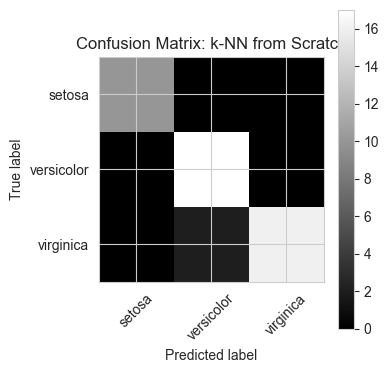

In [27]:
# TODO 6: 평가 함수를 완성한다.
def accuracy_score_from_scratch(y_true, y_pred):
    # 올바르게 예측한 샘플의 비율을 반환한다.
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    return correct / total


# 직접 혼동 행렬을 계산하는 함수를 정의한다.
def confusion_matrix_from_scratch(y_true, y_pred, n_classes):
    # 행은 실제 라벨, 열은 예측 라벨인 행렬을 만든다.
    matrix = np.zeros((n_classes, n_classes), dtype=int)

    for true_label, pred_label in zip(y_true, y_pred):
        matrix[true_label, pred_label] += 1

    return matrix


# 직접 구현한 정확도와 혼동 행렬을 계산한다.
acc = accuracy_score_from_scratch(y_test, y_pred)
conf = confusion_matrix_from_scratch(y_test, y_pred, n_classes=len(class_names))

# k값, 정확도, 혼동 행렬을 출력한다.
print(f'k = {k}, accuracy = {acc:.3f}')
print(conf)

# 여기서 부터는 시각화
# 혼동 행렬을 시각화할 그림 영역을 만든다.
plt.figure(figsize=(4, 4))

# 혼동 행렬을 회색 이미지로 표시한다.
plt.imshow(conf, cmap='gray')

# x축 눈금에 예측 품종 이름을 표시한다.
plt.xticks(range(len(class_names)), class_names, rotation=45)

# y축 눈금에 실제 품종 이름을 표시한다.
plt.yticks(range(len(class_names)), class_names)

# x축과 y축 이름을 지정한다.
plt.xlabel('Predicted label')
plt.ylabel('True label')

# 그래프 제목을 지정한다.
plt.title('Confusion Matrix: k-NN from Scratch')

# 색상 막대를 추가한다.
plt.colorbar()

# 그래프 요소가 겹치지 않도록 배치를 조정한다.
plt.tight_layout()


### Step 7. Experiment with different `k` values

Try `k = 1, 3, 5, 7, 9, 15`.  
Plot the accuracy for each value of `k`.

Then answer the questions below.

1. Which `k` value gives the highest test accuracy?
2. Does a larger `k` always improve accuracy?
3. What could happen if `k` is too small?
4. What could happen if `k` is too large?

k values: [1, 3, 5, 7, 9, 15]
accuracies: [np.float64(0.9555555555555556), np.float64(0.9555555555555556), np.float64(0.9333333333333333), np.float64(0.9777777777777777), np.float64(0.9777777777777777), np.float64(0.9555555555555556)]


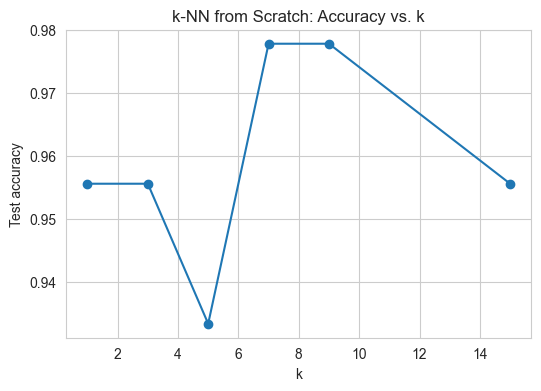

In [29]:
# TODO 7: k값 변화 실험을 완성한다.
k_values = [1, 3, 5, 7, 9, 15]  # 실험할 k값 목록을 저장한다.
accuracies = []  # 각 k값의 정확도를 저장할 빈 리스트를 만든다.

# 여러 k값에 대해 예측과 정확도 계산을 반복한다.
for k in k_values:
    y_pred = knn_predict(X_test_scaled, X_train_scaled, y_train, k=k)
    acc = accuracy_score_from_scratch(y_test, y_pred)
    accuracies.append(acc)

# 실험한 k값과 각 정확도를 출력한다.
print('k values:', k_values)
print('accuracies:', accuracies)

# 정확도 변화를 그릴 그림 영역을 만든다.
plt.figure(figsize=(6, 4))
# k값에 따른 정확도를 선 그래프로 그린다.
plt.plot(k_values, accuracies, marker='o')
# x축과 y축 이름을 지정한다.
plt.xlabel('k')
plt.ylabel('Test accuracy')
# 그래프 제목을 지정한다.
plt.title('k-NN from Scratch: Accuracy vs. k')
# 격자선을 표시한다.
plt.grid(True)
# 그래프를 화면에 보여준다.
plt.show()
